# Candidate Test 2022 Analysis Part 1

This assignment is about Danish candidate-test data from DR and TV2. I was given questionnaire answers from political candidates, where answers are on a scale from -2 to 2. The task was first to do descriptive analysis, such as age, confidence, and disagreement between parties, and then to predict party affiliation from the candidates’ answers. The machine learning part is supervised multiclass classification, because the correct party label is known during training, and the target is a category: the candidate’s party

## Imports

In [19]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.base import clone

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [20]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [21]:
party_colors = {
    "Socialdemokratiet": "#b72722",
    "Radikale Venstre": "#7b3f8c",
    "Det Konservative Folkeparti": "#9dbb21",
    "Nye Borgerlige": "#0d4c59",
    "Socialistisk Folkeparti": "#e0007a",
    "Liberal Alliance": "#31b7c2",
    "Kristendemokraterne": "#bfbfbf",
    "Moderaterne": "#6a3ddb",
    "Dansk Folkeparti": "#e7c23a",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#19a64a",
    "Venstre": "#006b9a",
    "Danmarksdemokraterne": "#7eaee0",
    "Enhedslisten": "#f28c18",
    "Alternativet": "#3b9a3f",
    "Løsgænger": "#666666",
}

## Load Data

In [22]:
all_data = pd.read_excel("alldata.xlsx")
dr_data = pd.read_excel("drdata.xlsx")
tv2_data = pd.read_excel("tv2data.xlsx")
drq_data = pd.read_excel("drq.xlsx")
tv2q_data = pd.read_excel("tv2q.xlsx")
elected_data = pd.read_excel("electeddata.xlsx")

print("All candidates Data:", all_data.shape)
print("DR candidates:", dr_data.shape)
print("TV2 candidates:", tv2_data.shape)
print("Elected candidates:", elected_data.shape)
display(all_data.head())

All candidates Data: (867, 53)
DR candidates: (904, 27)
TV2 candidates: (962, 28)
Elected candidates: (169, 53)


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


## Initial Overview

In [23]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 867 entries, 0 to 866
Data columns (total 53 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   530        867 non-null    int64 
 1   531        867 non-null    int64 
 2   533        867 non-null    int64 
 3   534        867 non-null    int64 
 4   535        867 non-null    int64 
 5   537        867 non-null    int64 
 6   538        867 non-null    int64 
 7   540        867 non-null    int64 
 8   541        867 non-null    int64 
 9   543        867 non-null    int64 
 10  544        867 non-null    int64 
 11  545        867 non-null    int64 
 12  546        867 non-null    int64 
 13  547        867 non-null    int64 
 14  548        867 non-null    int64 
 15  550        867 non-null    int64 
 16  551        867 non-null    int64 
 17  552        867 non-null    int64 
 18  553        867 non-null    int64 
 19  555        867 non-null    int64 
 20  556        867 non-null    int64

In [24]:
display(all_data.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
530,867.0,NaN,NaN,NaN,0.378316,1.423131,-2.0,-1.0,1.0,2.0,2.0
531,867.0,NaN,NaN,NaN,-0.303345,1.615893,-2.0,-2.0,-1.0,1.0,2.0
533,867.0,NaN,NaN,NaN,-0.489043,1.529029,-2.0,-2.0,-1.0,1.0,2.0
534,867.0,NaN,NaN,NaN,-1.131488,1.386595,-2.0,-2.0,-2.0,-1.0,2.0
535,867.0,NaN,NaN,NaN,0.94925,1.353196,-2.0,1.0,1.0,2.0,2.0
537,867.0,NaN,NaN,NaN,-0.126874,1.543086,-2.0,-2.0,-1.0,1.0,2.0
538,867.0,NaN,NaN,NaN,-0.974625,1.332418,-2.0,-2.0,-2.0,1.0,2.0
540,867.0,NaN,NaN,NaN,0.410611,1.521145,-2.0,-1.0,1.0,2.0,2.0
541,867.0,NaN,NaN,NaN,-0.294118,1.570514,-2.0,-2.0,-1.0,1.0,2.0
543,867.0,NaN,NaN,NaN,0.136101,1.526494,-2.0,-1.0,1.0,1.0,2.0


### Interpretation

Each row represents one candidate. The response columns contain answers to candidate-test questions on a scale from -2 to 2, while columns such as name, party, district and age are metadata.

This overview is used to check whether the data loaded correctly and whether there are obvious missing-value or type issues before modelling.

## Data Cleaning And Feature Definition

In [25]:
# Age equal to 0 is not a valid age, so it is treated as missing.
for data in [all_data, dr_data, tv2_data, elected_data]:
    if "alder" in data.columns:
        data["alder"] = data["alder"].replace(0, np.nan)

candidate_info_cols = ["navn", "parti", "storkreds", "alder"]
feature_cols = [col for col in all_data.columns if col not in candidate_info_cols]

print("Number of response features:", len(feature_cols))
print("Duplicate rows:", all_data.duplicated().sum())
display(all_data.isna().sum().sort_values(ascending=False).head(10))

Number of response features: 49
Duplicate rows: 0


alder    16
1a        0
2a        0
2b        0
3a        0
3b        0
4a        0
4b        0
5a        0
5b        0
dtype: int64

In [26]:
response_min = all_data[feature_cols].min().min()
response_max = all_data[feature_cols].max().max()
unique_values = sorted(pd.unique(all_data[feature_cols].values.ravel()))

print("Response range:", response_min, "to", response_max)
print("Unique response values:", unique_values)

Response range: -2 to 2
Unique response values: [-2, -1, 0, 1, 2]


### Interpretation

The response features are already numerical and use the expected candidate-test scale from -2 to 2.

The only simple cleaning step needed here is replacing invalid age values with missing values. The classification models below use only response features, so missing ages do not affect the model input.

## Descriptive Analysis

parti
Det Konservative Folkeparti                    98
Socialdemokratiet                              87
Venstre                                        84
Enhedslisten                                   74
Socialistisk Folkeparti                        70
Liberal Alliance                               70
Alternativet                                   67
Radikale Venstre                               67
Nye Borgerlige                                 51
Dansk Folkeparti                               49
Moderaterne                                    42
Kristendemokraterne                            42
Danmarksdemokraterne                           37
Frie Grønne, Danmarks Nye Venstrefløjsparti    26
Løsgænger                                       3
Name: count, dtype: int64

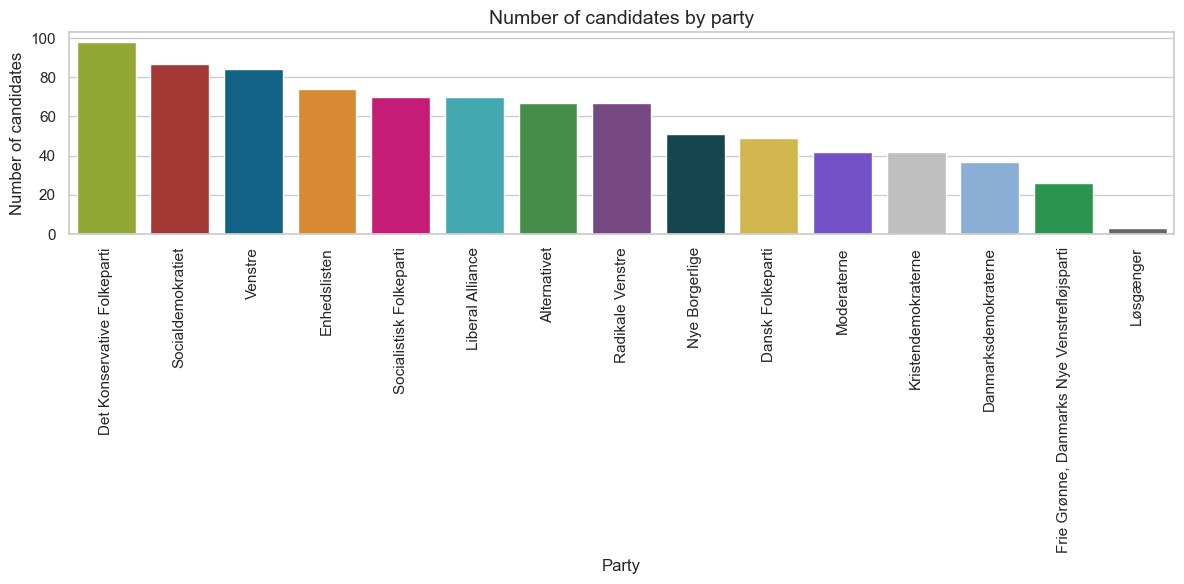

In [27]:
party_counts = all_data["parti"].value_counts()
party_order = party_counts.index.tolist()
party_palette = [party_colors.get(party, "#999999") for party in party_order]

display(party_counts)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=party_counts.index,
    y=party_counts.values,
    hue=party_counts.index,
    palette=party_palette,
    legend=False,
)
plt.xticks(rotation=90)
plt.ylabel("Number of candidates")
plt.xlabel("Party")
plt.title("Number of candidates by party")
plt.tight_layout()
plt.show()

In [28]:
age_summary = (
    all_data.groupby("parti")["alder"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean")
)

display(age_summary)

,count,mean,median,min,max
parti,,,,,
"Frie Grønne, Danmarks Nye Venstrefløjsparti",26,34.807692,33.0,20.0,62.0
Liberal Alliance,68,37.970588,37.0,18.0,72.0
Socialistisk Folkeparti,69,41.521739,42.0,20.0,68.0
Enhedslisten,71,42.225352,41.0,19.0,74.0
Moderaterne,42,44.261905,45.0,19.0,78.0
Det Konservative Folkeparti,94,44.723404,48.0,20.0,66.0
Radikale Venstre,67,44.955224,45.0,21.0,76.0
Socialdemokratiet,85,45.388235,45.0,20.0,78.0
Dansk Folkeparti,49,45.530612,47.0,20.0,75.0


### Interpretation

The parties are not equally represented in the dataset. This matters for classification because a model can achieve a high accuracy while still performing worse for smaller parties.

For that reason, macro F1 is used together with accuracy later. Macro F1 gives each party equal weight.

## Visualization With Box Plots

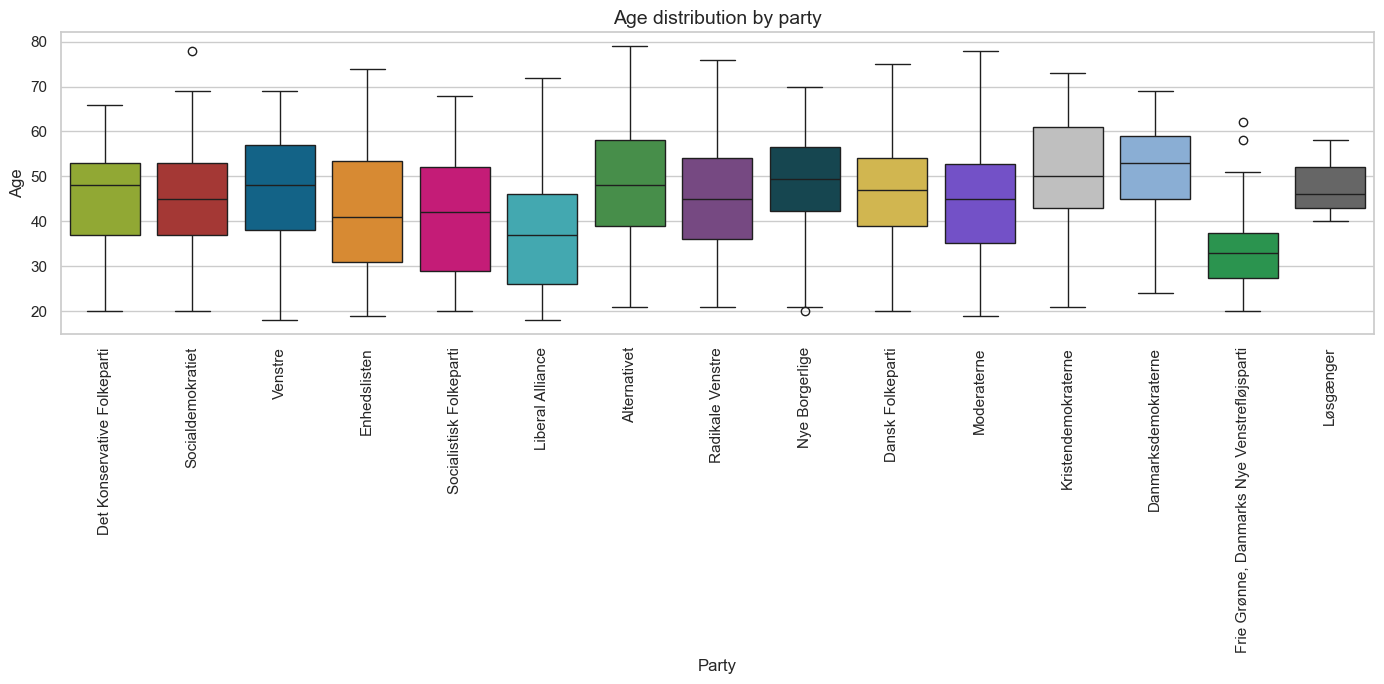

In [29]:
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=all_data,
    x="parti",
    y="alder",
    order=party_order,
    hue="parti",
    palette=party_colors,
    legend=False,
)
plt.xticks(rotation=90)
plt.xlabel("Party")
plt.ylabel("Age")
plt.title("Age distribution by party")
plt.tight_layout()
plt.show()

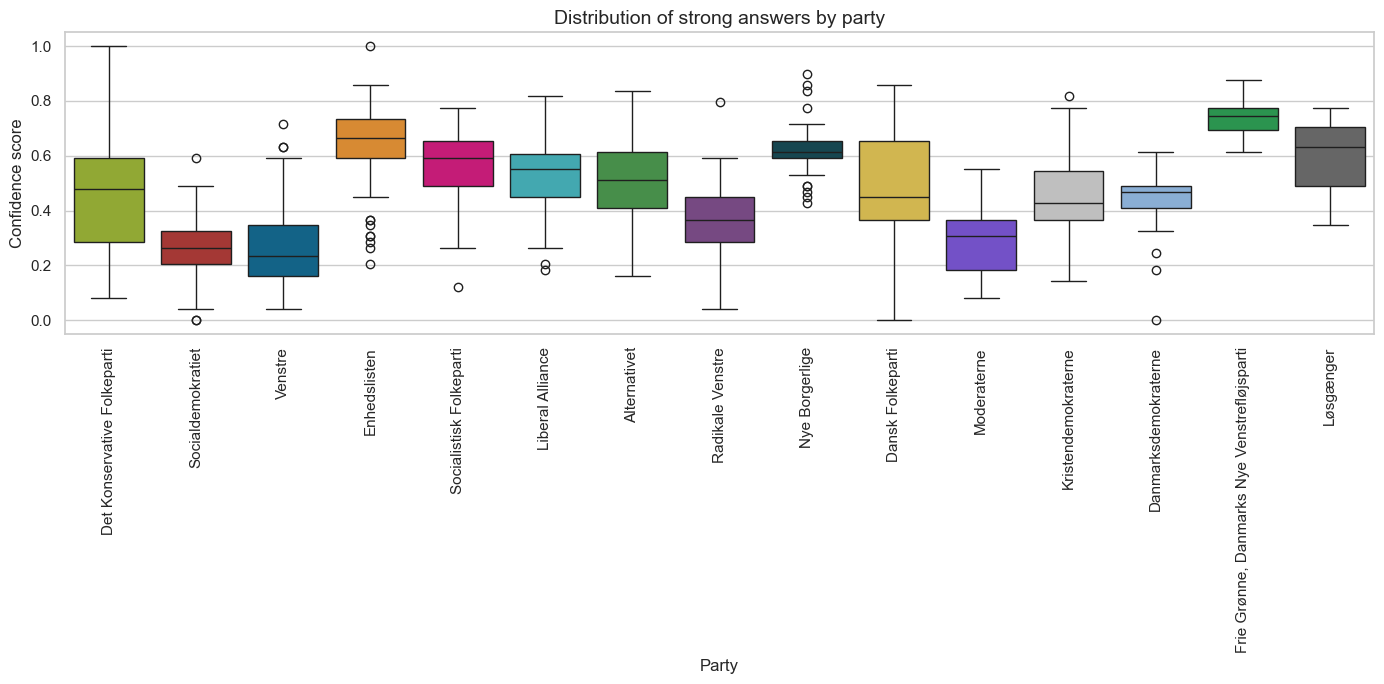

In [30]:
# Confidence score: proportion of strong answers (-2 or 2).
all_data["confidence_score"] = (all_data[feature_cols].abs() == 2).mean(axis=1)

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=all_data,
    x="parti",
    y="confidence_score",
    order=party_order,
    hue="parti",
    palette=party_colors,
    legend=False,
)
plt.xticks(rotation=90)
plt.xlabel("Party")
plt.ylabel("Confidence score")
plt.title("Distribution of strong answers by party")
plt.tight_layout()
plt.show()

### Interpretation

The age box plot describes candidate demographics, while the confidence-score box plot is directly based on the answer patterns used for classification.

The confidence score measures how often a candidate chooses a strong answer instead of a neutral or moderate answer. It is descriptive only and is not used as an extra model feature.

## Classification Problem Setup

In [ ]:
# The independent candidate class has only three observations.
# It is removed because stratified splitting and classification are unstable for such a small class.
final_data = all_data[all_data["parti"] != "Løsgænger"].copy()

X = final_data[feature_cols] # feature -> Candidate's answers.
y = final_data["parti"] # target 

label_encoder = LabelEncoder() # converts party names to numeric labels.
y_encoded = label_encoder.fit_transform(y) # fit = learns, transform = applies.

print("Model data shape:", X.shape)
display(y.value_counts())

Model data shape: (864, 49)


parti
Det Konservative Folkeparti                    98
Socialdemokratiet                              87
Venstre                                        84
Enhedslisten                                   74
Socialistisk Folkeparti                        70
Liberal Alliance                               70
Alternativet                                   67
Radikale Venstre                               67
Nye Borgerlige                                 51
Dansk Folkeparti                               49
Moderaterne                                    42
Kristendemokraterne                            42
Danmarksdemokraterne                           37
Frie Grønne, Danmarks Nye Venstrefløjsparti    26
Name: count, dtype: int64

# Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded, # use encoded numeric labels for stratification
    test_size=0.2,
    stratify=y_encoded, # Balance the weighted class same
    random_state=42,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (691, 49)
Test shape: (173, 49)


### Interpretation

The target is party affiliation and the input features are only the candidate-test answers.

The split is stratified so that party proportions are approximately preserved in train and test sets. The test set is kept untouched until the final evaluation.

## Baseline Model

In [33]:
baseline = DummyClassifier(strategy="most_frequent") # always predicts the most common class in the training data.
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Baseline Model accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline Model macro F1:", f1_score(y_test, baseline_pred, average="macro"))

Baseline Model accuracy: 0.11560693641618497
Baseline Model macro F1: 0.014803849000740192


### Interpretation

The baseline always predicts the most frequent party. Real classification models should clearly outperform this baseline, otherwise they are not learning useful answer patterns.

## Classification Algorithms

# 1. Decision Tree
A Decision Tree is a classification model that works like a flowchart.
# 2. Random Forest
A Random Forest is a collection of many Decision Trees.

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, # level
        min_samples_leaf=5, # min 5 candidates.
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, # 100 decision trees in the forest.
        min_samples_leaf=2, # min 2 candidates.

        random_state=42,
        n_jobs=1, # use 1 cpu core.
    ),
    "Gradient-Boosted Trees": GradientBoostingClassifier( # sequential, new tree correct previous errors
        max_depth=3, # level
        learning_rate=0.05, # model learns slowly to prevent overfitting
        n_estimators=80,
        random_state=42,
    ),
}

cross_val = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
}

## Decision Tree

In [36]:
decision_tree_model = clone(models["Decision Tree"])
decision_tree_scores = cross_validate(
    decision_tree_model, 
    X_train, 
    y_train, 
    cv=cross_val, 
    scoring=scoring)

print("Decision Tree CV accuracy:", decision_tree_scores["test_accuracy"].mean())
print("Decision Tree CV macro F1:", decision_tree_scores["test_macro_f1"].mean())

Decision Tree CV accuracy: 0.6917686178555744
Decision Tree CV macro F1: 0.6793885648187152


,feature,importance
3,534,0.153342
20,556,0.119616
36,6b,0.115960
5,537,0.106097
46,11b,0.096697
13,547,0.090473
37,7a,0.060005
15,550,0.054234
30,3b,0.053185
4,535,0.031287


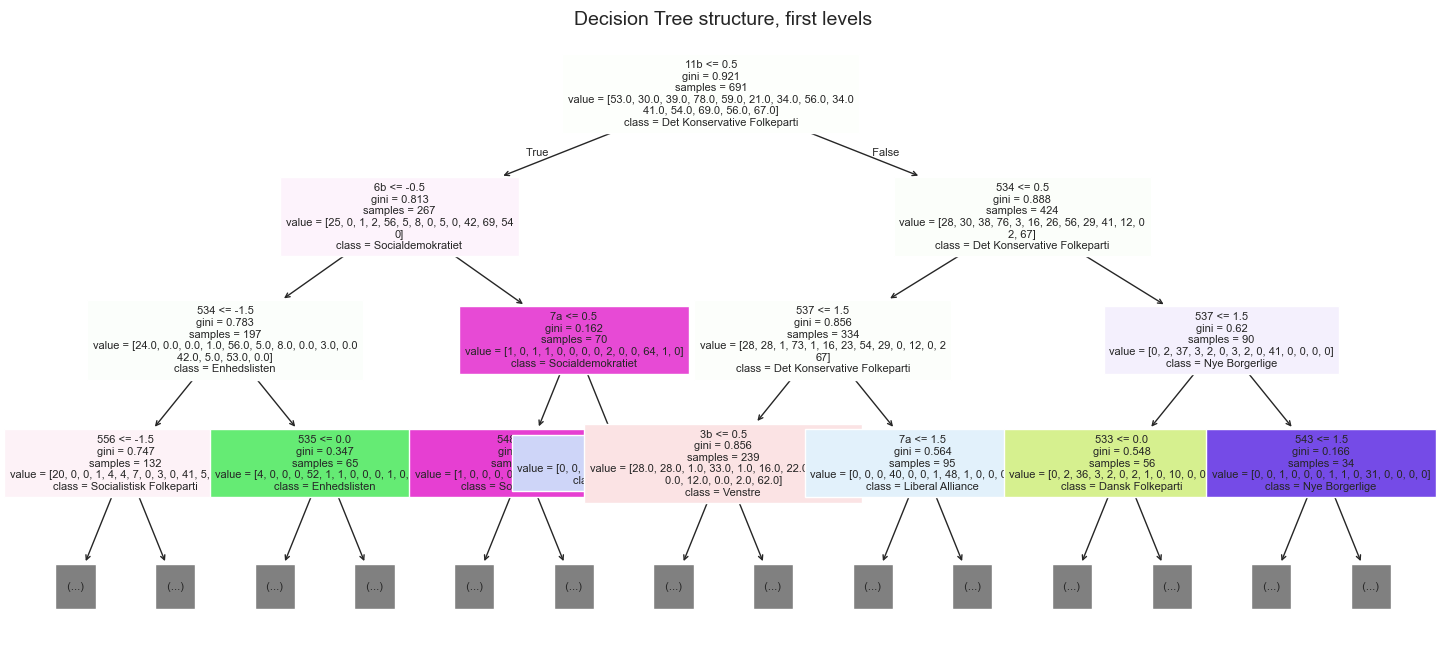

In [37]:
decision_tree_model.fit(X_train, y_train)

decision_tree_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": decision_tree_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(decision_tree_importance.head(10))

plt.figure(figsize=(18, 8))
plot_tree(
    decision_tree_model,
    feature_names=feature_cols,
    class_names=label_encoder.classes_,
    max_depth=3,
    filled=True,
    fontsize=8,
)
plt.title("Decision Tree structure, first levels")
plt.show()

### Interpretation

A decision tree is easy to explain because it predicts by following a sequence of question-based splits.

The trade-off is that a single tree can overfit: it may learn very specific patterns from the training data instead of general party-level patterns. Limiting depth and requiring several samples per leaf helps reduce this risk.

## Random Forest

In [38]:
random_forest_model = clone(models["Random Forest"])
rf_scores = cross_validate(
    random_forest_model, 
    X_train, 
    y_train, 
    cv=cross_val, 
    scoring=scoring)

print("Random Forest CV accuracy:", rf_scores["test_accuracy"].mean())
print("Random Forest CV macro F1:", rf_scores["test_macro_f1"].mean())

Random Forest CV accuracy: 0.885670368279064
Random Forest CV macro F1: 0.8884361045897181


,feature,importance
3,534,0.062247
13,547,0.049845
20,556,0.047043
44,10b,0.041979
46,11b,0.037500
1,531,0.036786
35,6a,0.035826
37,7a,0.033828
12,546,0.033329
45,11a,0.032271


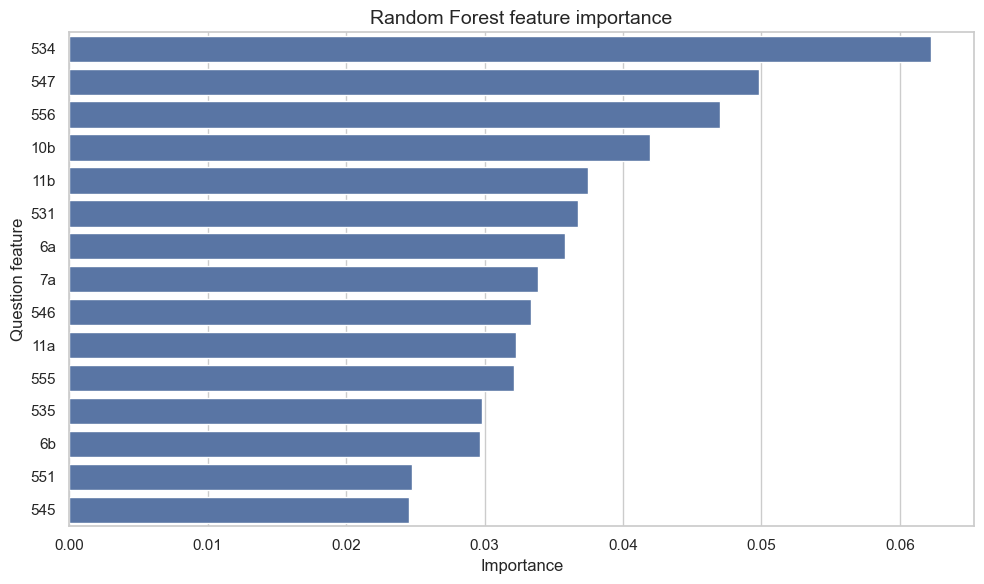

In [ ]:
random_forest_model.fit(X_train, y_train) # fit = trains the model on the training data, learning patterns and relationships.

random_forest_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": random_forest_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(random_forest_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=random_forest_importance.head(15), x="importance", y="feature")
plt.xlabel("Importance")
plt.ylabel("Question feature")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

### Interpretation

A random forest trains many decision trees on different bootstrap samples and feature subsets. Averaging many trees usually reduces variance and improves generalization compared with one tree.

Feature importance is model-specific. It shows which questions helped this random forest classify parties, but it should not be interpreted as causal political importance.

## Gradient-Boosted Trees

In [40]:
gradient_boosted_model = clone(models["Gradient-Boosted Trees"])
gbt_scores = cross_validate(
    gradient_boosted_model, 
    X_train, y_train, 
    cv=cross_val, 
    scoring=scoring)

print("Gradient-Boosted Trees CV accuracy:", gbt_scores["test_accuracy"].mean())
print("Gradient-Boosted Trees CV macro F1:", gbt_scores["test_macro_f1"].mean())

Gradient-Boosted Trees CV accuracy: 0.8394002133132568
Gradient-Boosted Trees CV macro F1: 0.8313405027482471


### Interpretation

Gradient-boosted trees are built sequentially. Each new tree tries to improve the errors made by the previous trees.

This can give strong predictive performance, but the model can overfit if too many trees are used or if the learning rate and depth are too aggressive.

## Cross-Validation Model Comparison

In [41]:
cross_val_results = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cross_val, scoring=scoring)
    cross_val_results.append({
        "model": name,
        "mean_accuracy": scores["test_accuracy"].mean(),
        "std_accuracy": scores["test_accuracy"].std(),
        "mean_macro_f1": scores["test_macro_f1"].mean(),
        "std_macro_f1": scores["test_macro_f1"].std(),
    })

cv_results_df = (
    pd.DataFrame(cross_val_results)
    .sort_values("mean_macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df)

,model,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1
0,Random Forest,0.885670,0.005471,0.888436,0.010948
1,Gradient-Boosted Trees,0.839400,0.018065,0.831341,0.028495
2,Decision Tree,0.691769,0.031367,0.679389,0.044947


### Interpretation

The models are compared using cross-validation on the training data only. This gives a more stable estimate than one split and keeps the test set untouched for final evaluation.

Accuracy measures overall correctness, while macro F1 is important because the parties are imbalanced and smaller parties should still count.

## Final Model

In [42]:
best_model_name = cv_results_df.loc[0, "model"]
final_model = clone(models[best_model_name])

final_model.fit(X_train, y_train) # train best model on full training data.
y_test_pred = final_model.predict(X_test) # predict test labels using the best model trained on the full training set.

print("Best model from CV:", best_model_name)
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test macro F1:", f1_score(y_test, y_test_pred, average="macro"))
print()
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

Best model from CV: Random Forest
Test accuracy: 0.9190751445086706
Test macro F1: 0.9156509316122939

                                             precision    recall  f1-score   support

                               Alternativet       0.87      0.93      0.90        14
                       Danmarksdemokraterne       1.00      1.00      1.00         7
                           Dansk Folkeparti       0.91      1.00      0.95        10
                Det Konservative Folkeparti       1.00      0.75      0.86        20
                               Enhedslisten       1.00      1.00      1.00        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       1.00      0.60      0.75         5
                        Kristendemokraterne       1.00      0.75      0.86         8
                           Liberal Alliance       0.78      1.00      0.88        14
                                Moderaterne       0.89      1.00      0.94         8
                             Nye Borgerlige   

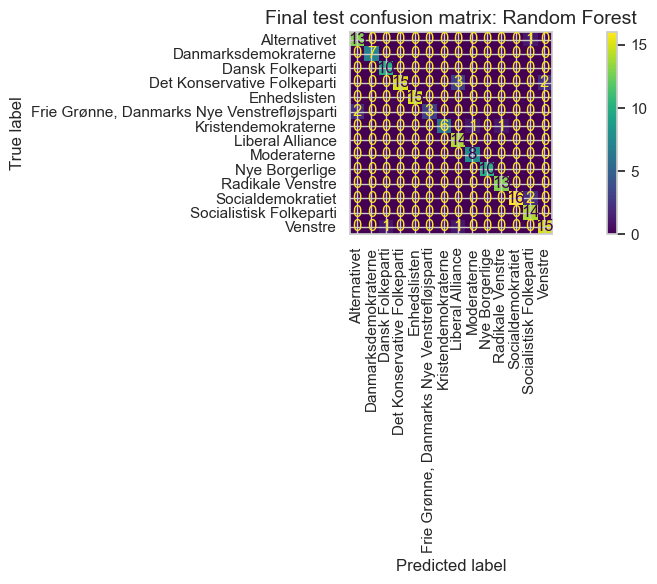

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
)
plt.title(f"Final test confusion matrix: {best_model_name}")
plt.tight_layout()
plt.show()

### Interpretation

The final model is selected using cross-validation on the training data and evaluated once on the held-out test set.

The confusion matrix shows which parties are most often confused with each other. This is useful because errors between ideologically similar parties may be more expected than errors between very different parties.

## Candidates Potentially Associated With Another Party

In [52]:
# This is an exploratory model-based analysis, not a final test evaluation.
rf_cv_pred = cross_val_predict(
    clone(models["Random Forest"]),
    X,
    y_encoded,
    cv=cross_val,
    method="predict",
)

rf_cv_proba = cross_val_predict(
    clone(models["Random Forest"]),
    X,
    y_encoded,
    cv=cross_val,
    method="predict_proba",
)

candidate_signals = final_data[["navn", "parti"]].copy()
candidate_signals["predicted_party"] = label_encoder.inverse_transform(rf_cv_pred)
candidate_signals["correct"] = candidate_signals["parti"] == candidate_signals["predicted_party"]
candidate_signals["true_party_probability"] = rf_cv_proba[np.arange(len(final_data)), y_encoded]

display(
    candidate_signals
    [candidate_signals["correct"] == False]
    .sort_values("true_party_probability")
    .head(20)
)

,navn,parti,predicted_party,correct,true_party_probability
653,Finn Andersen,Kristendemokraterne,Socialdemokratiet,False,0.026667
679,Mads Silberg,Det Konservative Folkeparti,Kristendemokraterne,False,0.032500
37,Gustav Juul,Venstre,Det Konservative Folkeparti,False,0.069500
140,Bo Sandroos,Venstre,Det Konservative Folkeparti,False,0.072167
326,Diana-Ester Eriksen,Det Konservative Folkeparti,Dansk Folkeparti,False,0.083833
163,Jon Læssøe Stephensen,Moderaterne,Alternativet,False,0.088095
250,Phillip Sperling,Venstre,Liberal Alliance,False,0.088167
674,Claus Bedemann,Nye Borgerlige,Dansk Folkeparti,False,0.104167
816,Lars Prier,Dansk Folkeparti,Det Konservative Folkeparti,False,0.110000
666,Jeanne Bergmansen,Socialistisk Folkeparti,Radikale Venstre,False,0.113333


### Interpretation

These candidates were predicted as another party by the Random Forest model.

This does not necessarily mean they are politically closer to another party in reality. It only means that, based on their questionnaire answers, the model associated their answer pattern more strongly with another party than with their actual party.

The `true_party_probability` column shows how much probability the model assigned to the candidate’s real party. Lower values suggest that the candidate’s answers looked less typical for their actual party according to the model, but this should not be treated as ground truth.

## Conclusion

This notebook uses candidate-test answers to predict party affiliation with tree-based classification algorithms.

The descriptive analysis shows party imbalance and differences in candidate answer behavior. The classification part compares a single decision tree, a random forest and gradient-boosted trees using cross-validation on the training data.

The final test evaluation is done only once after model selection, which makes the evaluation easier to defend.

## Limitations

The responses are self-reported and may not fully represent real political behavior.

Party affiliation is also not a perfect ground-truth label for ideology. Candidates from the same party can disagree, and candidates from different parties can answer similarly.

The dataset is imbalanced, so accuracy alone is not enough. Macro F1 is included because it gives smaller parties equal weight.

Tree-based feature importance is model-specific and should not be interpreted as causal importance.